1. Generate data and save it

In [51]:
# generate_data.py
import numpy as np
import scipy.linalg
import os

def generate_case1_samples(category, num_samples):
    """Case 1: third-order system A = [[0,1,0],[0,0,1],[-a0,-a1,-a2]], B = [[0],[0],[1]]"""
    inputs, outputs = [], []
    n = 3
    m = 1
    
    while len(inputs) < num_samples:
        if category == "case1_stable":
            a0, a1, a2 = np.random.uniform(0.1, 3, 3)
            if not (a2 * a1 > a0):
                continue
        elif category == "case1_unstable":
            a0, a1, a2 = np.random.uniform(-2, 2, 3)
            A = np.array([[0, 1, 0],
                          [0, 0, 1],
                          [-a0, -a1, -a2]])
            eig_vals = np.linalg.eig(A)[0]
            if np.max(eig_vals.real) <= 0.1:
                continue
        elif category == "case1_oscillatory":
            a0, a1, a2 = np.random.uniform(-2, 2, 3)
            A = np.array([[0, 1, 0],
                          [0, 0, 1],
                          [-a0, -a1, -a2]])
            eig_vals = np.linalg.eig(A)[0]
            if not np.any(np.abs(eig_vals.imag) > 0.1):
                continue
        
        A = np.array([[0, 1, 0],
                      [0, 0, 1],
                      [-a0, -a1, -a2]])
        B = np.array([[0],
                      [0],
                      [1]])
        
        Q = np.diag(np.random.rand(n) + 0.1)
        R = np.diag(np.random.rand(m) + 0.1)
        
        try:
            P = scipy.linalg.solve_continuous_are(A, B, Q, R)
        except:
            continue
        
        B_padded = np.zeros((n, n))
        B_padded[:, :B.shape[1]] = B
        R_padded = np.zeros((n, n))
        R_padded[:R.shape[0], :R.shape[1]] = R
        
        input_vector = np.concatenate([
            A.flatten(), 
            B_padded.flatten(), 
            Q.flatten(), 
            R_padded.flatten()
        ])
        
        inputs.append(input_vector)
        outputs.append(P.flatten())
        
        if len(inputs) % 500 == 0:
            print(f"Generated {category} samples: {len(inputs)}/{num_samples}")
    
    return np.array(inputs), np.array(outputs)

def generate_case2_samples(category, num_samples):
    """Case 2: decoupled system A = [[0,1,0],[-a0,-a1,0],[0,0,-a3]], B = [[0,0],[1,0],[0,1]]"""
    inputs, outputs = [], []
    n = 3
    m = 2
    
    while len(inputs) < num_samples:
        if category == "case2_stable":
            a0, a1, a3 = np.random.uniform(0.1, 2, 3)
        elif category == "case2_fully_unstable":
            if np.random.rand() > 0.5:
                a0, a1 = np.random.uniform(-2, -0.1, 2)
                a3 = np.random.uniform(-2, -0.1)
            else:
                a0, a1 = np.random.uniform(-2, 2, 2)
                a3 = np.random.uniform(-2, -0.1)
                if a0 > 0 and a1 > 0:
                    a0 = -a0
        elif category == "case2_mixed":
            if np.random.rand() > 0.5:
                a0, a1 = np.random.uniform(0.1, 2, 2)
                a3 = np.random.uniform(-2, -0.1)
            else:
                a0, a1 = np.random.uniform(-2, 2, 2)
                if a0 > 0 and a1 > 0:
                    a0 = -a0
                a3 = np.random.uniform(0.1, 2)
        elif category == "case2_oscillatory":
            a0 = np.random.uniform(1, 2)
            a1 = np.random.uniform(0, 1)
            a3 = np.random.uniform(-2, 2)
        
        A = np.array([[0, 1, 0],
                      [-a0, -a1, 0],
                      [0, 0, -a3]])
        B = np.array([[0, 0],
                      [1, 0],
                      [0, 1]])
        
        eig_vals = np.linalg.eig(A)[0]
        real_parts = eig_vals.real
        imag_parts = np.abs(eig_vals.imag)
        second_order_eigs = eig_vals[:2]
        first_order_eig = eig_vals[2]
        
        second_order_stable = np.all(second_order_eigs.real < 0)
        second_order_unstable = np.any(second_order_eigs.real > 0)
        first_order_stable = first_order_eig.real < 0
        first_order_unstable = first_order_eig.real > 0
        has_complex = np.any(imag_parts > 1e-6)
        
        valid = False
        if category == "case2_stable" and second_order_stable and first_order_stable:
            valid = True
        elif category == "case2_fully_unstable" and second_order_unstable and first_order_unstable:
            valid = True
        elif category == "case2_mixed" and ((second_order_stable and first_order_unstable) or 
                                          (second_order_unstable and first_order_stable)):
            valid = True
        elif category == "case2_oscillatory" and has_complex:
            valid = True
            
        if not valid:
            continue
            
        Q = np.diag(np.random.rand(n) + 0.1)
        R = np.diag(np.random.rand(m) + 0.1)
        
        try:
            P = scipy.linalg.solve_continuous_are(A, B, Q, R)
        except:
            continue
        
        B_padded = np.zeros((n, n))
        B_padded[:, :B.shape[1]] = B
        R_padded = np.zeros((n, n))
        R_padded[:R.shape[0], :R.shape[1]] = R
        
        input_vector = np.concatenate([
            A.flatten(), 
            B_padded.flatten(), 
            Q.flatten(), 
            R_padded.flatten()
        ])
        
        inputs.append(input_vector)
        outputs.append(P.flatten())
        
        if len(inputs) % 500 == 0:
            print(f"Generated {category} samples: {len(inputs)}/{num_samples}")
    
    return np.array(inputs), np.array(outputs)

def generate_case3_samples(category, num_samples):
    """Case 3: diagonal system A = [[a0,0,0],[0,a1,0],[0,0,a2]], B = [[1,0,0],[0,1,0],[0,0,1]]"""
    inputs, outputs = [], []
    n = 3
    m = 3
    
    while len(inputs) < num_samples:
        if category == "case3_fully_stable":
            a0, a1, a2 = np.random.uniform(-2, -0.1, 3)
        elif category == "case3_fully_unstable":
            a0, a1, a2 = np.random.uniform(0.1, 2, 3)
        elif category == "case3_two_stable_one_unstable":
            unstable_idx = np.random.randint(0, 3)
            a_values = np.random.uniform(-2, -0.1, 3)
            a_values[unstable_idx] = np.random.uniform(0.1, 2)
            a0, a1, a2 = a_values
        elif category == "case3_one_stable_two_unstable":
            stable_idx = np.random.randint(0, 3)
            a_values = np.random.uniform(0.1, 2, 3)
            a_values[stable_idx] = np.random.uniform(-2, -0.1)
            a0, a1, a2 = a_values
            
        A = np.array([[a0, 0, 0],
                      [0, a1, 0],
                      [0, 0, a2]])
        B = np.array([[1, 0, 0],
                      [0, 1, 0],
                      [0, 0, 1]])
        
        eig_vals = np.linalg.eig(A)[0]
        stable_count = np.sum(eig_vals < 0)
        unstable_count = np.sum(eig_vals > 0)
        
        valid = False
        if category == "case3_fully_stable" and stable_count == 3:
            valid = True
        elif category == "case3_fully_unstable" and unstable_count == 3:
            valid = True
        elif category == "case3_two_stable_one_unstable" and stable_count == 2 and unstable_count == 1:
            valid = True
        elif category == "case3_one_stable_two_unstable" and stable_count == 1 and unstable_count == 2:
            valid = True
            
        if not valid:
            continue
            
        Q = np.diag(np.random.rand(n) + 0.1)
        R = np.diag(np.random.rand(m) + 0.1)
        
        try:
            P = scipy.linalg.solve_continuous_are(A, B, Q, R)
        except:
            continue
        
        input_vector = np.concatenate([
            A.flatten(), 
            B.flatten(), 
            Q.flatten(), 
            R.flatten()
        ])
        
        inputs.append(input_vector)
        outputs.append(P.flatten())
        
        if len(inputs) % 500 == 0:
            print(f"Generated {category} samples: {len(inputs)}/{num_samples}")
    
    return np.array(inputs), np.array(outputs)

def split_data_by_type(inputs_list, outputs_list, train_ratio=0.8):
    """Split training and test sets by type"""
    train_inputs, train_outputs = [], []
    test_inputs, test_outputs = [], []
    
    for inputs, outputs in zip(inputs_list, outputs_list):
        split_idx = int(len(inputs) * train_ratio)
        train_inputs.append(inputs[:split_idx])
        train_outputs.append(outputs[:split_idx])
        test_inputs.append(inputs[split_idx:])
        test_outputs.append(outputs[split_idx:])
    
    return (np.vstack(train_inputs), np.vstack(train_outputs),
            np.vstack(test_inputs), np.vstack(test_outputs))

def generate_position_grid(rows=3, cols=3):
    """Generate position coordinate grid"""
    grid = []
    for i in range(rows):
        for j in range(cols):
            x_norm = i / (rows - 1) if rows > 1 else 0.5
            y_norm = j / (cols - 1) if cols > 1 else 0.5
            grid.append([x_norm, y_norm])
    return np.array(grid)

# Set random seed for reproducibility
# np.random.seed(42)

print("Generating fused training data...")
# Case 1
case1_stable_inputs, case1_stable_outputs = generate_case1_samples('case1_stable', 1000)
case1_unstable_inputs, case1_unstable_outputs = generate_case1_samples('case1_unstable', 1000)
case1_oscillatory_inputs, case1_oscillatory_outputs = generate_case1_samples('case1_oscillatory', 1000)

# Case 2
case2_stable_inputs, case2_stable_outputs = generate_case2_samples('case2_stable', 1200)
case2_fully_unstable_inputs, case2_fully_unstable_outputs = generate_case2_samples('case2_fully_unstable', 1200)
case2_mixed_inputs, case2_mixed_outputs = generate_case2_samples('case2_mixed', 2400)
case2_oscillatory_inputs, case2_oscillatory_outputs = generate_case2_samples('case2_oscillatory', 1200)

# Case 3
case3_fully_stable_inputs, case3_fully_stable_outputs = generate_case3_samples('case3_fully_stable', 1500)
case3_fully_unstable_inputs, case3_fully_unstable_outputs = generate_case3_samples('case3_fully_unstable', 1500)
case3_two_stable_one_unstable_inputs, case3_two_stable_one_unstable_outputs = generate_case3_samples('case3_two_stable_one_unstable', 1500)
case3_one_stable_two_unstable_inputs, case3_one_stable_two_unstable_outputs = generate_case3_samples('case3_one_stable_two_unstable', 1500)

print("Data generation completed:")
print(f"Case 1 - Stable: {len(case1_stable_inputs)}, Unstable: {len(case1_unstable_inputs)}, Oscillatory: {len(case1_oscillatory_inputs)}")
print(f"Case 2 - Stable: {len(case2_stable_inputs)}, Fully unstable: {len(case2_fully_unstable_inputs)}, Mixed: {len(case2_mixed_inputs)}, Oscillatory: {len(case2_oscillatory_inputs)}")
print(f"Case 3 - Fully stable: {len(case3_fully_stable_inputs)}, Fully unstable: {len(case3_fully_unstable_inputs)}, Two stable one unstable: {len(case3_two_stable_one_unstable_inputs)}, One stable two unstable: {len(case3_one_stable_two_unstable_inputs)}")

# Combine all data
all_inputs_list = [
    case1_stable_inputs, case1_unstable_inputs, case1_oscillatory_inputs,
    case2_stable_inputs, case2_fully_unstable_inputs, case2_mixed_inputs, case2_oscillatory_inputs,
    case3_fully_stable_inputs, case3_fully_unstable_inputs, 
    case3_two_stable_one_unstable_inputs, case3_one_stable_two_unstable_inputs
]

all_outputs_list = [
    case1_stable_outputs, case1_unstable_outputs, case1_oscillatory_outputs,
    case2_stable_outputs, case2_fully_unstable_outputs, case2_mixed_outputs, case2_oscillatory_outputs,
    case3_fully_stable_outputs, case3_fully_unstable_outputs,
    case3_two_stable_one_unstable_outputs, case3_one_stable_two_unstable_outputs
]

# Split data
train_inputs, train_outputs, test_inputs, test_outputs = split_data_by_type(
    all_inputs_list, all_outputs_list
)

print(f"Total training set: {len(train_inputs)}, Total test set: {len(test_inputs)}")

# Generate position grid
position_grid = generate_position_grid(3, 3)
print(f"Position grid shape: {position_grid.shape}")

# Save data to 3D folder
save_dir = "3D_test"
os.makedirs(save_dir, exist_ok=True)

np.save(os.path.join(save_dir, "train_inputs.npy"), train_inputs)
np.save(os.path.join(save_dir, "train_outputs.npy"), train_outputs)
np.save(os.path.join(save_dir, "test_inputs.npy"), test_inputs)
np.save(os.path.join(save_dir, "test_outputs.npy"), test_outputs)
np.save(os.path.join(save_dir, "position_grid.npy"), position_grid)

print(f"Data has been saved to folder '{save_dir}'.")

Generating fused training data...
Generated case1_stable samples: 500/1000
Generated case1_stable samples: 1000/1000
Generated case1_unstable samples: 500/1000
Generated case1_unstable samples: 1000/1000
Generated case1_oscillatory samples: 500/1000
Generated case1_oscillatory samples: 1000/1000
Generated case2_stable samples: 500/1200
Generated case2_stable samples: 1000/1200
Generated case2_fully_unstable samples: 500/1200
Generated case2_fully_unstable samples: 1000/1200
Generated case2_mixed samples: 500/2400
Generated case2_mixed samples: 1000/2400
Generated case2_mixed samples: 1500/2400
Generated case2_mixed samples: 2000/2400
Generated case2_oscillatory samples: 500/1200
Generated case2_oscillatory samples: 1000/1200
Generated case3_fully_stable samples: 500/1500
Generated case3_fully_stable samples: 1000/1500
Generated case3_fully_stable samples: 1500/1500
Generated case3_fully_unstable samples: 500/1500
Generated case3_fully_unstable samples: 1000/1500
Generated case3_fully_u

2. Train the model and save it

In [58]:
# train_model.py
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class DeepONet(nn.Module):
    """DeepONet neural network model"""
    def __init__(self, branch_input_dim=36, trunk_input_dim=2, hidden_dim=256):
        super().__init__()
        self.branch_net = nn.Sequential(
            nn.Linear(branch_input_dim, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, hidden_dim)
        )
        self.trunk_net = nn.Sequential(
            nn.Linear(trunk_input_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, hidden_dim)
        )
        self.output_layer = nn.Linear(hidden_dim, 1)
        
    def forward(self, branch_input, trunk_input):
        branch_out = self.branch_net(branch_input)  # (batch_size, hidden_dim)
        batch_size, num_points, coord_dim = trunk_input.shape
        trunk_flat = trunk_input.view(-1, coord_dim)
        trunk_out = self.trunk_net(trunk_flat)  # (batch_size*num_points, hidden_dim)
        trunk_out = trunk_out.view(batch_size, num_points, -1)
        branch_out = branch_out.unsqueeze(1)  # (batch_size, 1, hidden_dim)
        combined = branch_out * trunk_out  # (batch_size, num_points, hidden_dim)
        output = self.output_layer(combined).squeeze(-1)  # (batch_size, num_points)
        return output

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Load data
data_dir = "3D_test"
train_inputs = np.load(os.path.join(data_dir, "train_inputs.npy"))
train_outputs = np.load(os.path.join(data_dir, "train_outputs.npy"))
test_inputs = np.load(os.path.join(data_dir, "test_inputs.npy"))
test_outputs = np.load(os.path.join(data_dir, "test_outputs.npy"))
position_grid = np.load(os.path.join(data_dir, "position_grid.npy"))

print(f"Data loaded: training set {train_inputs.shape}, test set {test_inputs.shape}")

# Convert to tensors
train_branch_tensor = torch.FloatTensor(train_inputs).to(device)
train_output_tensor = torch.FloatTensor(train_outputs).to(device)
train_grid_tensor = torch.FloatTensor(
    np.tile(position_grid, (len(train_inputs), 1, 1))
).to(device)

test_branch_tensor = torch.FloatTensor(test_inputs).to(device)
test_output_tensor = torch.FloatTensor(test_outputs).to(device)
test_grid_tensor = torch.FloatTensor(
    np.tile(position_grid, (len(test_inputs), 1, 1))
).to(device)

# Create model
model = DeepONet(hidden_dim=256).to(device)
print(f"Number of model parameters: {count_parameters(model):,}")

# Training parameters
num_epochs = 1500
learning_rate = 1e-4

optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
criterion = nn.MSELoss()

train_losses = []
test_losses = []

print("Starting training...")
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    train_pred = model(train_branch_tensor, train_grid_tensor)
    train_loss = criterion(train_pred, train_output_tensor)
    train_loss.backward()
    optimizer.step()
    
    model.eval()
    with torch.no_grad():
        test_pred = model(test_branch_tensor, test_grid_tensor)
        test_loss = criterion(test_pred, test_output_tensor)
    
    train_losses.append(train_loss.item())
    test_losses.append(test_loss.item())
    
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {train_loss.item():.6f}, '
              f'Test Loss: {test_loss.item():.6f}')

print("Training completed.")

# Save model
model_dir = "3D_test"
os.makedirs(model_dir, exist_ok=True)
model_path = os.path.join(model_dir, "deeponet_model.pth")
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")

# save
loss_history_path = os.path.join(model_dir, "loss_history_10.npz")
np.savez(loss_history_path, train_losses=train_losses, test_losses=test_losses)
print(f"Loss history saved to {loss_history_path}")

Using device: cuda
Data loaded: training set (12000, 36), test set (3000, 36)
Number of model parameters: 381,441
Starting training...
Epoch [100/1500], Train Loss: 0.957019, Test Loss: 0.899652
Epoch [200/1500], Train Loss: 0.501789, Test Loss: 0.490280
Epoch [300/1500], Train Loss: 0.371771, Test Loss: 0.369707
Epoch [400/1500], Train Loss: 0.260779, Test Loss: 0.263076
Epoch [500/1500], Train Loss: 0.207406, Test Loss: 0.214437
Epoch [600/1500], Train Loss: 0.177118, Test Loss: 0.182847
Epoch [700/1500], Train Loss: 0.110712, Test Loss: 0.111588
Epoch [800/1500], Train Loss: 0.081990, Test Loss: 0.081410
Epoch [900/1500], Train Loss: 0.065573, Test Loss: 0.065497
Epoch [1000/1500], Train Loss: 0.056856, Test Loss: 0.056934
Epoch [1100/1500], Train Loss: 0.049673, Test Loss: 0.049583
Epoch [1200/1500], Train Loss: 0.041929, Test Loss: 0.041502
Epoch [1300/1500], Train Loss: 0.033273, Test Loss: 0.032757
Epoch [1400/1500], Train Loss: 0.019425, Test Loss: 0.020045
Epoch [1500/1500], T

3. Draw a picture and save it


Final test results:
Final test loss (MSE): 0.009501
Mean absolute error (MAE): 0.058945

Starting stability verification (using all test samples)...

Stability verification results (all 3000 test samples):
Systems stable with true P matrix: 3000/3000 (100.0%)
Systems stable with predicted P matrix: 3000/3000 (100.0%)
Stable eigenvalue ratio with true P matrix: 9000/9000 (100.00%) (theoretically 100%)
Stable eigenvalue ratio with predicted P matrix: 9000/9000 (100.00%) (std 0.00%)
Stability summary saved to 3D_test\stability_summary_10.txt


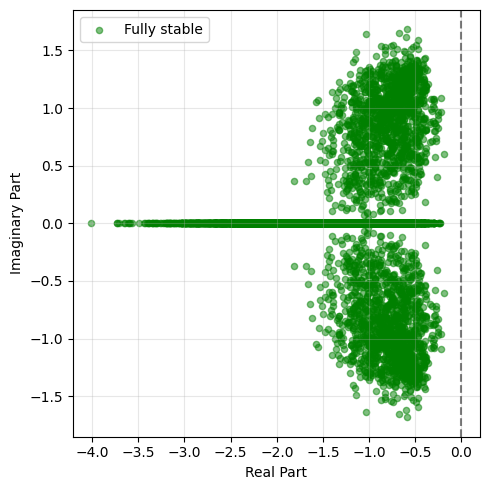

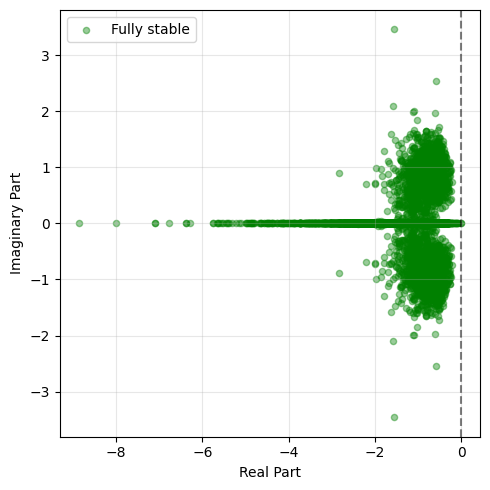


Stability prediction accuracy: 3000/3000 (100.00%)


In [59]:
import matplotlib.pyplot as plt
def verify_stability_all_samples(model, test_inputs, test_outputs, grid):
    """
    Verify whether the predicted P matrix for all test samples can stabilize the original system
    """
    model.eval()
    
    stability_results = []
    eigenvalue_data = []
    
    # Process all test samples
    for idx in range(len(test_inputs)):
        # Extract system parameters from input data
        input_vector = test_inputs[idx]
        
        # Parse input vector (A, B, Q, R)
        A_flat = input_vector[:9]  # first 9 elements are A matrix
        B_flat = input_vector[9:18]  # next 9 elements are B matrix
        Q_flat = input_vector[18:27]  # next 9 elements are Q matrix
        R_flat = input_vector[27:36]  # last 9 elements are R matrix
        
        # Reshape to matrix form
        A = A_flat.reshape(3, 3)
        B = B_flat.reshape(3, 3)
        Q = Q_flat.reshape(3, 3)
        R = R_flat.reshape(3, 3)
        
        # Get true P matrix
        true_P_flat = test_outputs[idx]
        true_P = true_P_flat.reshape(3, 3)
        
        # Predict P matrix using model
        with torch.no_grad():
            input_tensor = torch.FloatTensor(input_vector).unsqueeze(0).to(device)
            grid_tensor = torch.FloatTensor(grid).unsqueeze(0).to(device)
            pred_P_flat = model(input_tensor, grid_tensor).cpu().numpy()[0]
            pred_P = pred_P_flat.reshape(3, 3)
        
        # Determine actual dimensions of B and R
        # Check number of nonzero columns in B
        B_nonzero_cols = np.sum(np.any(B != 0, axis=0))
        if B_nonzero_cols == 1:
            # Case 1: B is 3x1
            B_actual = B[:, 0:1]
            R_actual = np.array([[R[0, 0]]])
        elif B_nonzero_cols == 2:
            # Case 2: B is 3x2
            B_actual = B[:, :2]
            R_actual = R[:2, :2]
        else:
            # Case 3: B is 3x3
            B_actual = B
            R_actual = R
        
        # Compute feedback gain matrix K = R^(-1) * B^T * P
        try:
            K_true = np.linalg.inv(R_actual) @ B_actual.T @ true_P
            K_pred = np.linalg.inv(R_actual) @ B_actual.T @ pred_P
        except:
            continue
        
        # Compute closed-loop system matrix A_cl = A - B * K
        A_cl_true = A - B_actual @ K_true
        A_cl_pred = A - B_actual @ K_pred
        
        # Compute eigenvalues
        eig_true = np.linalg.eig(A_cl_true)[0]
        eig_pred = np.linalg.eig(A_cl_pred)[0]
        
        # Check stability (all eigenvalues real part < 0)
        stable_true = np.all(eig_true.real < 0)
        stable_pred = np.all(eig_pred.real < 0)
        
        stability_results.append({
            'index': idx,
            'stable_true': stable_true,
            'stable_pred': stable_pred,
            'eig_true': eig_true,
            'eig_pred': eig_pred,
            'true_P': true_P,  # added: store true P matrix
            'pred_P': pred_P,  # added: store predicted P matrix
            'A': A,  # added: store system matrix A
            'B_actual': B_actual,  # added: store actual B matrix used
            'R_actual': R_actual,  # added: store actual R matrix used
            'Q': Q           # added: store actual Q matrix used
        })
        
        # Collect eigenvalue data for plotting
        for eig in eig_true:
            eigenvalue_data.append({
                'real': eig.real,
                'imag': eig.imag,
                'type': 'True P',
                'stable': stable_true
            })
        for eig in eig_pred:
            eigenvalue_data.append({
                'real': eig.real,
                'imag': eig.imag,
                'type': 'Predicted P',
                'stable': stable_pred
            })
    
    return stability_results, eigenvalue_data

def plot_stability_analysis_all(stability_results, eigenvalue_data):
    """Plot stability analysis results for all test samples"""
    
    # Compute stability statistics
    true_stable_count = sum(1 for r in stability_results if r['stable_true'])
    pred_stable_count = sum(1 for r in stability_results if r['stable_pred'])
    total_count = len(stability_results)

    # Compute eigenvalue-level stability ratios and total stable eigenvalues
    true_total_stable_eigs = 0
    pred_total_stable_eigs = 0
    true_stable_eig_ratios = []
    pred_stable_eig_ratios = []
    
    for r in stability_results:
        true_eigs = r['eig_true']
        pred_eigs = r['eig_pred']
        true_stable = np.sum(true_eigs.real < 0)
        pred_stable = np.sum(pred_eigs.real < 0)
        true_total_stable_eigs += true_stable
        pred_total_stable_eigs += pred_stable
        true_stable_ratio = true_stable / len(true_eigs)
        pred_stable_ratio = pred_stable / len(pred_eigs)
        true_stable_eig_ratios.append(true_stable_ratio)
        pred_stable_eig_ratios.append(pred_stable_ratio)
    
    true_avg_ratio = np.mean(true_stable_eig_ratios)
    pred_avg_ratio = np.mean(pred_stable_eig_ratios)
    pred_std_ratio = np.std(pred_stable_eig_ratios)
    
    total_eigs = total_count * 3  # 3 eigenvalues per sample
    
    print(f"\nStability verification results (all {total_count} test samples):")
    print(f"Systems stable with true P matrix: {true_stable_count}/{total_count} ({true_stable_count/total_count*100:.1f}%)")
    print(f"Systems stable with predicted P matrix: {pred_stable_count}/{total_count} ({pred_stable_count/total_count*100:.1f}%)")
    print(f"Stable eigenvalue ratio with true P matrix: {true_total_stable_eigs}/{total_eigs} ({true_total_stable_eigs/total_eigs*100:.2f}%) (theoretically 100%)")
    print(f"Stable eigenvalue ratio with predicted P matrix: {pred_total_stable_eigs}/{total_eigs} ({pred_total_stable_eigs/total_eigs*100:.2f}%) (std {pred_std_ratio*100:.2f}%)")

    # ========== Save stability statistics to file ==========
    output_dir = "3D_test"
    os.makedirs(output_dir, exist_ok=True)
    summary_path = os.path.join(output_dir, "stability_summary_10.txt")
    
    with open(summary_path, 'w', encoding='utf-8') as f:
        f.write("Stability Verification Results\n")
        f.write("=============================\n\n")
        f.write(f"Total test samples: {total_count}\n")
        f.write(f"Systems stable with true P matrix: {true_stable_count}/{total_count} ({true_stable_count/total_count*100:.1f}%)\n")
        f.write(f"Systems stable with predicted P matrix: {pred_stable_count}/{total_count} ({pred_stable_count/total_count*100:.1f}%)\n")
        f.write(f"Stable eigenvalue ratio with true P matrix: {true_total_stable_eigs}/{total_eigs} ({true_total_stable_eigs/total_eigs*100:.2f}%) (theoretically 100%)\n")
        f.write(f"Stable eigenvalue ratio with predicted P matrix: {pred_total_stable_eigs}/{total_eigs} ({pred_total_stable_eigs/total_eigs*100:.2f}%) (std {pred_std_ratio*100:.2f}%)\n")
    
    print(f"Stability summary saved to {summary_path}")
    


    # Create eigenvalue distribution plot
    plt.figure(figsize=(5, 5))
    
    # Subplot 1: eigenvalue distribution for true P matrix
    true_eigs = [e for e in eigenvalue_data if e['type'] == 'True P']
    stable_true = [e for e in true_eigs if e['stable']]
    unstable_left_true = [e for e in true_eigs if not e['stable'] and e['real'] < 0]
    unstable_right_true = [e for e in true_eigs if not e['stable'] and e['real'] >= 0]
    
    if stable_true:
        plt.scatter([e['real'] for e in stable_true], [e['imag'] for e in stable_true], 
                   c='green', marker='o', label='Fully stable', alpha=0.5, s=20)
    if unstable_left_true:
        plt.scatter([e['real'] for e in unstable_left_true], [e['imag'] for e in unstable_left_true], 
                   c='blue', marker='x', label='Partially stable (stable mode)', alpha=0.9, s=60)
    if unstable_right_true:
        plt.scatter([e['real'] for e in unstable_right_true], [e['imag'] for e in unstable_right_true], 
                   c='red', marker='x', label='Partially stable (unstable mode)', alpha=0.9, s=60)
    
    plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
    plt.xlabel('Real Part')
    plt.ylabel('Imaginary Part')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    #plt.savefig('3D/True_P.png', dpi=300)
    plt.show()
    
    # Subplot 2: eigenvalue distribution for predicted P matrix
    plt.figure(figsize=(5, 5))
    pred_eigs = [e for e in eigenvalue_data if e['type'] == 'Predicted P']
    stable_pred = [e for e in pred_eigs if e['stable']]
    unstable_left_pred = [e for e in pred_eigs if not e['stable'] and e['real'] < 0]
    unstable_right_pred = [e for e in pred_eigs if not e['stable'] and e['real'] >= 0]
    
    if stable_pred:
        plt.scatter([e['real'] for e in stable_pred], [e['imag'] for e in stable_pred], 
                   c='green', marker='o', label='Fully stable', alpha=0.4, s=20)
    if unstable_left_pred:
        plt.scatter([e['real'] for e in unstable_left_pred], [e['imag'] for e in unstable_left_pred], 
                   c='blue', marker='x', label='Partially stable (stable mode)', alpha=0.9, s=80)
    if unstable_right_pred:
        plt.scatter([e['real'] for e in unstable_right_pred], [e['imag'] for e in unstable_right_pred], 
                   c='red', marker='x', label='Partially stable (unstable mode)', alpha=0.9, s=80)
    
    plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
    plt.xlabel('Real Part')
    plt.ylabel('Imaginary Part')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    #plt.savefig('3D/Predict_P.png', dpi=300)
    plt.show()
    
    # Print details of some unstable systems
    unstable_cases = [r for r in stability_results if not r['stable_pred']]
    if unstable_cases:
        print(f"\nFound {len(unstable_cases)} systems that are unstable with predicted P matrix:")
        for i, case in enumerate(unstable_cases[:5]):  # show first 5 only
            print(f"  Case {i+1} (index: {case['index']}):")
            print(f"    True eigenvalues: {case['eig_true']}")
            print(f"    Predicted eigenvalues: {case['eig_pred']}")
            print(f"    True P matrix:")
            print(f"    {case['true_P']}")
            print(f"    Predicted P matrix:")
            print(f"    {case['pred_P']}")
            print(f"    System matrix A:")
            print(f"    {case['A']}")
            print(f"    Control matrix B:")
            print(f"    {case['B_actual']}")
            print(f"    Weight matrix Q:")
            print(f"    {case['Q']}")
            print(f"    Weight matrix R:")
            print(f"    {case['R_actual']}")
            
            # Compute relative error of P matrix
            P_error = np.linalg.norm(case['pred_P'] - case['true_P']) / np.linalg.norm(case['true_P'])
            print(f"    Relative error of P matrix: {P_error:.4f}")
            print()
            
    # Compute and display prediction accuracy
    correct_stability = sum(1 for r in stability_results if r['stable_true'] == r['stable_pred'])
    accuracy = correct_stability / total_count * 100
    print(f"\nStability prediction accuracy: {correct_stability}/{total_count} ({accuracy:.2f}%)")


# Final test
print("\nFinal test results:")
model.eval()
with torch.no_grad():
    test_predictions = model(test_branch_tensor, test_grid_tensor)
    final_test_loss = criterion(test_predictions, test_output_tensor)
    mae = torch.mean(torch.abs(test_predictions - test_output_tensor))
    
    print(f"Final test loss (MSE): {final_test_loss.item():.6f}")
    print(f"Mean absolute error (MAE): {mae.item():.6f}")

# ==================== Perform stability verification ====================

print("\nStarting stability verification (using all test samples)...")
stability_results, eigenvalue_data = verify_stability_all_samples(
    model, test_inputs, test_outputs, position_grid
)

plot_stability_analysis_all(stability_results, eigenvalue_data)

In [11]:
# ==================== Theorem verification: compute error norm and threshold ====================
import numpy.linalg as LA

def compute_delta(P_true, A, B, Q, R):
    """
    Compute threshold according to theorem: delta = λ_min(Q + K^T R K) / (2 ||B||^2 ||R^{-1}|| ||P*||)
    where K = R^{-1} B^T P*
    """
    # Compute true feedback gain K
    K_true = LA.solve(R, B.T @ P_true)  # equivalent to inv(R) @ B.T @ P_true
    # Compute Q + K^T R K
    Q_plus = Q + K_true.T @ R @ K_true
    # Minimum eigenvalue (Q_plus is symmetric positive definite, use eigvalsh for stability)
    lambda_min = np.min(LA.eigvalsh(Q_plus))
    # Denominator terms
    norm_B = LA.norm(B, ord=2)
    norm_Rinv = LA.norm(LA.inv(R), ord=2)
    norm_P = LA.norm(P_true, ord=2)
    denominator = 2 * (norm_B**2) * norm_Rinv * norm_P
    # Avoid division by zero (denominator should theoretically be > 0)
    if denominator == 0:
        return np.inf
    return lambda_min / denominator

# Separate stable and unstable samples from stability_results
unstable_samples = [r for r in stability_results if not r['stable_pred']]
stable_samples = [r for r in stability_results if r['stable_pred']]

print("\n" + "="*60)
print("Theorem verification: compute error norm ||E|| and threshold δ")
print("="*60)
print(f"Number of unstable samples: {len(unstable_samples)}")
print(f"Number of stable samples: {len(stable_samples)}")

# Analyze unstable samples
unstable_data = []
for r in unstable_samples:
    P_true = r['true_P']
    P_pred = r['pred_P']
    A = r['A']
    B = r['B_actual']
    Q = r['Q']
    R = r['R_actual']
    
    E = P_pred - P_true
    norm_E = LA.norm(E, ord=2)
    delta = compute_delta(P_true, A, B, Q, R)
    
    unstable_data.append({
        'index': r['index'],
        'norm_E': norm_E,
        'delta': delta,
        'satisfied': norm_E < delta
    })

# Print statistics
print("\n--- Unstable samples statistics ---")
if unstable_data:
    norms_u = [d['norm_E'] for d in unstable_data]
    deltas_u = [d['delta'] for d in unstable_data]
    satisfied_u = sum(1 for d in unstable_data if d['satisfied'])
    print(f"Error norm range: {min(norms_u):.4e} ~ {max(norms_u):.4e}")
    print(f"δ range: {min(deltas_u):.4e} ~ {max(deltas_u):.4e}")
    print(f"Samples satisfying ||E|| < δ: {satisfied_u}/{len(unstable_data)} ({satisfied_u/len(unstable_data)*100:.2f}%)")
else:
    print("No unstable samples.")

# Show detailed information of all unstable samples
if unstable_data:
    print("\n" + "="*60)
    print("Detailed information of all unstable samples")
    print("="*60)
    for i, r in enumerate(unstable_samples):
        idx = r['index']
        # Retrieve corresponding data from unstable_data (order consistent)
        norm_E = unstable_data[i]['norm_E']
        delta = unstable_data[i]['delta']
        satisfied = unstable_data[i]['satisfied']
        
        A = r['A']
        eig_open = np.linalg.eigvals(A)  # open-loop eigenvalues
        eig_true_cl = r['eig_true']
        eig_pred_cl = r['eig_pred']
        
        print(f"\nUnstable sample {i+1} (index {idx}):")
        print(f"||E|| = {norm_E:.4e}, δ = {delta:.4e}, satisfies ||E|| < δ: {satisfied}")
        print("A matrix:")
        print(A)
        print("A matrix eigenvalues (open-loop):")
        print(eig_open)
        print("True closed-loop eigenvalues (using true P):")
        print(eig_true_cl)
        print("Predicted closed-loop eigenvalues (using predicted P):")
        print(eig_pred_cl)
        print("-" * 40)


Theorem verification: compute error norm ||E|| and threshold δ
Number of unstable samples: 1
Number of stable samples: 2999

--- Unstable samples statistics ---
Error norm range: 2.0266e-01 ~ 2.0266e-01
δ range: 8.1836e-03 ~ 8.1836e-03
Samples satisfying ||E|| < δ: 0/1 (0.00%)

Detailed information of all unstable samples

Unstable sample 1 (index 2771):
||E|| = 2.0266e-01, δ = 8.1836e-03, satisfies ||E|| < δ: False
A matrix:
[[-0.2366476   0.          0.        ]
 [ 0.          1.27434361  0.        ]
 [ 0.          0.          1.19557223]]
A matrix eigenvalues (open-loop):
[-0.2366476   1.27434361  1.19557223]
True closed-loop eigenvalues (using true P):
[-1.44998104 -1.51101791 -1.54112899]
Predicted closed-loop eigenvalues (using predicted P):
[ 0.22325717 -1.62319955 -1.40200437]
----------------------------------------
